In [1]:
from groundingdino.util.inference import load_model, load_image, predict, annotate, batch_predict
import cv2
import torch

model = load_model("groundingdino/config/GroundingDINO_SwinT_OGC.py", "groundingdino_swint_ogc.pth")
TEXT_PROMPT = "drone without the string"
BOX_TRESHOLD = 0.35
TEXT_TRESHOLD = 0.25


final text_encoder_type: bert-base-uncased


In [2]:
import os
from tqdm import tqdm

batch_size = 10
images = os.listdir("/Users/derek/Desktop/GroundingDINO/oct15")
TEXT_PATH = "/Users/derek/Desktop/GroundingDINO/labels"
IMAGES_PATH = "/Users/derek/Desktop/GroundingDINO/oct15"
images = os.listdir(IMAGES_PATH)

for i in tqdm(range(0, len(images), batch_size)):
    batch_images = images[i:i+batch_size]
    loaded_images = []
    for image in batch_images:
        image_source, image = load_image(os.path.join(IMAGES_PATH, image))
        loaded_images.append(image)
    input_images = torch.stack(loaded_images)
    boxes, logits, boxes_to_im = batch_predict(
        model=model,
        preprocessed_images=input_images,
        caption=TEXT_PROMPT,
        box_threshold=BOX_TRESHOLD,
        text_threshold=TEXT_TRESHOLD,
        device="cpu"
    )
    for im_num in range(len(batch_images)):
        # get all the boxes that correspond to this image
        im_boxes = boxes[torch.Tensor(boxes_to_im) == im_num]
        smallest_box = []
        smallest_area = float('inf')
        for box in im_boxes:
            area = box[2] * box[3]
            if area < smallest_area:
                smallest_area = area
                smallest_box = box
        # write the smallest box to a file
        with open(f"{TEXT_PATH}/{batch_images[im_num].split('.')[0]}.txt", "w") as f:
            f.write(f"0 {smallest_box[0]} {smallest_box[1]} {smallest_box[2]} {smallest_box[3]}")



 55%|█████▌    | 32/58 [06:47<05:31, 12.74s/it]


IndexError: list index out of range

[0.5002844333648682, 0.5158395171165466, 0.3672637343406677, 0.14101369678974152]


SupervisionWarnings: annotate is deprecated: `BoxAnnotator` is deprecated and will be removed in `supervision-0.22.0`. Use `BoundingBoxAnnotator` and `LabelAnnotator` instead


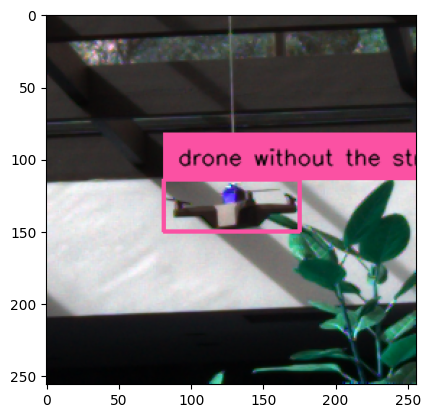

In [9]:
import cv2
import os
import torch
from groundingdino.util.inference import load_model, load_image, predict, annotate, batch_predict
from matplotlib import pyplot as plt

IMAGES_PATH = "/Users/derek/Desktop/GroundingDINO/oct15"
TEXT_PROMPT = "drone without the string"

def read_image_labels(path):
    with open(path, "r") as f:
        lines = f.readlines()
    split_lines = [line.split(" ") for line in lines]
    # return the first box
    return [float(x) for x in split_lines[0][1:]]

box = read_image_labels("/Users/derek/Desktop/GroundingDINO/labels/0001729009899445521.txt")
print(box)
im_source, im = load_image(os.path.join(IMAGES_PATH, "0001729009899445521.png"))
annotated_im = annotate(im_source, torch.Tensor([box]), torch.Tensor([1]), [TEXT_PROMPT])
    
plt.imshow(annotated_im)


In [4]:
im, im_source = load_image(os.path.join(IMAGES_PATH, "0001729009899445521.png"))

tensor([[[-1.8439, -1.8439, -1.8439,  ..., -1.9124, -1.9124, -1.9124],
         [-1.8439, -1.8439, -1.8439,  ..., -1.9124, -1.9124, -1.9124],
         [-1.8439, -1.8439, -1.8439,  ..., -1.9124, -1.9124, -1.9124],
         ...,
         [-2.0323, -2.0323, -2.0323,  ..., -0.8849, -0.8849, -0.8849],
         [-2.0323, -2.0323, -2.0323,  ..., -0.6965, -0.6794, -0.6794],
         [-2.0323, -2.0323, -2.0323,  ..., -0.6965, -0.6794, -0.6794]],

        [[-1.7556, -1.7556, -1.7381,  ..., -1.7906, -1.7906, -1.7906],
         [-1.7556, -1.7556, -1.7381,  ..., -1.7906, -1.7906, -1.7906],
         [-1.7556, -1.7556, -1.7381,  ..., -1.7906, -1.7906, -1.7906],
         ...,
         [-2.0007, -2.0007, -2.0007,  ..., -0.3200, -0.2850, -0.2850],
         [-2.0007, -2.0007, -2.0007,  ..., -0.0924, -0.0399, -0.0399],
         [-2.0007, -2.0007, -2.0007,  ..., -0.0924, -0.0399, -0.0399]],

        [[-1.4733, -1.4733, -1.4733,  ..., -1.5256, -1.5256, -1.5256],
         [-1.4733, -1.4733, -1.4733,  ..., -1

In [5]:
annotated_im = annotate(im_source, torch.Tensor([box]), torch.Tensor([1]), [TEXT_PROMPT])

error: OpenCV(4.10.0) :-1: error: (-5:Bad argument) in function 'cvtColor'
> Overload resolution failed:
>  - src is not a numpy array, neither a scalar
>  - Expected Ptr<cv::UMat> for argument 'src'
